In [1]:
import gymnasium as gym
import numpy as np
from typing import Optional, Tuple, Any
import sys
sys.path.append("..")

import tools.robots as robots
import tools.envs.navigation_envs as navigation_envs
import tools.planners as planners
from tools.utils.plot_graph import plot_graph_2d

from time import sleep

#
from gymnasium.utils.env_checker import check_env

import logging
logging.basicConfig(level=logging.DEBUG)
logger = logging.getLogger(__name__)

Successfully registered NavigationEnvBrokenRudder-v0


In [2]:
gym.register(
    id='NavigationEnv-v0',
    entry_point='tools.envs.navigation_envs.navigation_env:NavigationEnv',)

gym.register(
    id='NavigationEnvSingleIntegrator-v0',
    entry_point='tools.envs.navigation_envs.navigation_env_single_integrator:NavigationEnvSingleIntegrator',)

gym.register(
    id='NavigationEnvDoubleIntegrator-v0',
    entry_point='tools.envs.navigation_envs.navigation_env_double_integrator:NavigationEnvDoubleIntegrator',)

gym.register(
    id='NavigationEnvBaseline-v0',
    entry_point='tools.envs.navigation_envs.navigation_env_baseline:NavigationEnvBaseline',)

gym.register(
    id='NavigationEnvSingleIntegratorUnicycle-v0',
    entry_point='tools.envs.navigation_envs.navigation_env_single_integrator_unicycle:NavigationEnvSingleIntegratorUnicycle',)

gym.register(
    id='NavigationEnvSingleIntegratorBrokenRudder-v0',
    entry_point='tools.envs.navigation_envs.navigation_env_single_integrator_broken_rudder:NavigationEnvSingleIntegratorBrokenRudder',)

gym.register(
    id='NavigationEnvPololu-v0',
    entry_point='tools.envs.navigation_envs.navigation_env_pololu:NavigationEnvPololu',)

In [3]:
envs =['NavigationEnv-v0',
'NavigationEnvSingleIntegrator-v0',
'NavigationEnvDoubleIntegrator-v0',
'NavigationEnvBaseline-v0',
'NavigationEnvSingleIntegratorUnicycle-v0',
'NavigationEnvSingleIntegratorBrokenRudder-v0',
'NavigationEnvPololu-v0',]

key = 6
env = gym.make(envs[key], render_mode="ansi", multi_step_count=1)

/Users/christoph/Library/CloudStorage/SynologyDrive-Documents_Sync/research/projects/ann-cmcgs/.venv/lib/python3.11/site-packages/gymnasium/envs/registration.py:728: UserWarning: WARN: The environment is being initialised with render_mode='ansi' that is not in the possible render_modes ([]).
  logger.warn(
INFO:tools.envs.navigation_envs.navigation_env:---- Starting Initialization of NavigationEnv
/Users/christoph/Library/CloudStorage/SynologyDrive-Documents_Sync/research/projects/ann-cmcgs/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/Users/christoph/Library/CloudStorage/SynologyDrive-Documents_Sync/research/projects/ann-cmcgs/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
INFO:tools.envs.navigation_envs.navigation_env:--

---- Starting Initialization of NavigationEnvSingleIntegratorUnicycleSpace
---- Starting Initialization of NavigationEnvSingleIntegratorUnicycleSpace
---- Starting Initialization of NavigationEnvSingleIntegratorUnicycle
Starting initialization of SingleIntegrator
Finished initialization of SingleIntegrator
---- Finished Initialization of NavigationEnvSingleIntegratorUnicycle
Starting initialization of SingleIntegrator
Finished initialization of SingleIntegrator
---- Finished Initialization of NavigationEnvSingleIntegratorUnicycle
Starting initialization of SingleIntegrator
Finished initialization of SingleIntegrator
---- Finished Initialization of NavigationEnvSingleIntegratorUnicycle


In [4]:
env.reset(seed=42)
env.render()

INFO:tools.envs.navigation_envs.navigation_env:Using provided seed: 42


---- NavigationEnvSingleIntegratorUnicycle reset called with seed: 42 and options: None
start_obs: [0. 3. 0. 0. 9. 4.] goal_obs: [ 9.  4. nan nan  9.  4.]


'Agent state: [0. 3. 0. 0.], Goal: [ 9.  4. nan nan]'

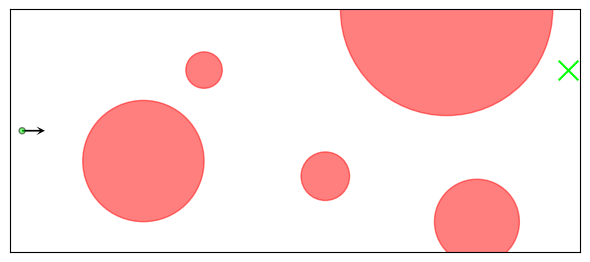

INFO:tools.envs.navigation_envs.navigation_env:---- Starting Initialization of NavigationEnv
INFO:tools.envs.navigation_envs.navigation_env:---- Finished Initialization of NavigationEnv
INFO:tools.robots.single_integrator_unicycle:Starting initialization of SingleIntegratorUnicycle
INFO:tools.robots.single_integrator_unicycle:Finished initialization of SingleIntegratorUnicycle
INFO:tools.robots.single_integrator_unicycle_space:Starting initialization of SingleIntegratorUnicycleSpace
INFO:tools.robots.single_integrator_unicycle:Starting initialization of SingleIntegratorUnicycle
INFO:tools.robots.single_integrator_unicycle:Finished initialization of SingleIntegratorUnicycle
INFO:tools.robots.single_integrator_unicycle_space:Finished initialization of SingleIntegratorUnicycleSpace
INFO:tools.robots.pololu:Starting initialization of Pololu
INFO:tools.robots.single_integrator_unicycle_space:Starting initialization of SingleIntegratorUnicycleSpace
INFO:tools.robots.single_integrator_unicycl

---- Starting Initialization of NavigationEnvSingleIntegratorUnicycleSpace
---- Starting Initialization of NavigationEnvSingleIntegratorUnicycleSpace
---- Starting Initialization of NavigationEnvSingleIntegratorUnicycle
Starting initialization of SingleIntegrator
Finished initialization of SingleIntegrator
---- Finished Initialization of NavigationEnvSingleIntegratorUnicycle
Starting initialization of SingleIntegrator
Finished initialization of SingleIntegrator
---- Finished Initialization of NavigationEnvSingleIntegratorUnicycle
Starting initialization of SingleIntegrator
Finished initialization of SingleIntegrator
---- Finished Initialization of NavigationEnvSingleIntegratorUnicycle
---- NavigationEnvSingleIntegratorUnicycle reset called with seed: None and options: None
start_obs: [0. 3. 0. 0. 9. 4.] goal_obs: [ 9.  4. nan nan  9.  4.]
---- Starting Initialization of NavigationEnvSingleIntegratorUnicycleSpace
---- Starting Initialization of NavigationEnvSingleIntegratorUnicycleSpace

<Figure size 1200x1200 with 0 Axes>

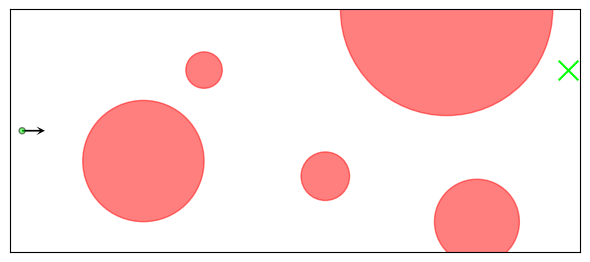

<Figure size 1200x1200 with 0 Axes>

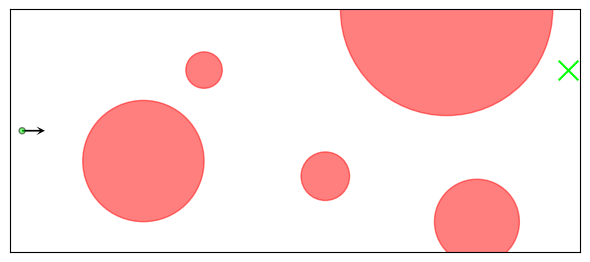

In [5]:

check_env(env.unwrapped, warn=True)

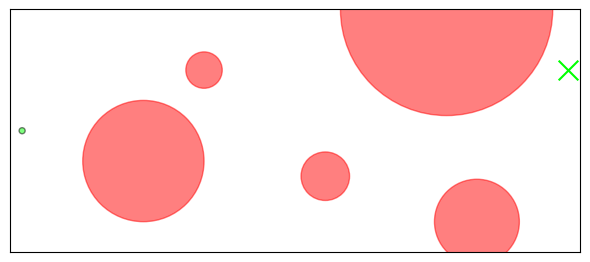

<Figure size 1200x1200 with 0 Axes>

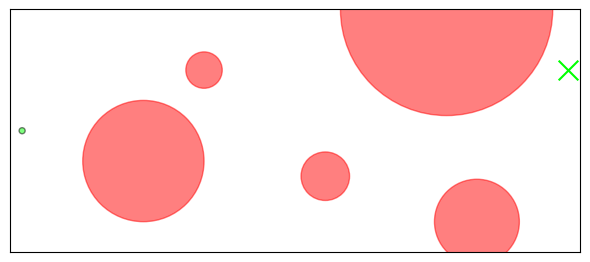

In [6]:
env = gym.make('NavigationEnvSingleIntegrator-v0', 
               render_mode="human",
               dt=1.0,
               atol=0.3,
               rtol=0.0,
               multi_step_count=5,
               plan_in_space_time=False,
               sparse_reward=True)
env.reset(seed=42)
env.render()


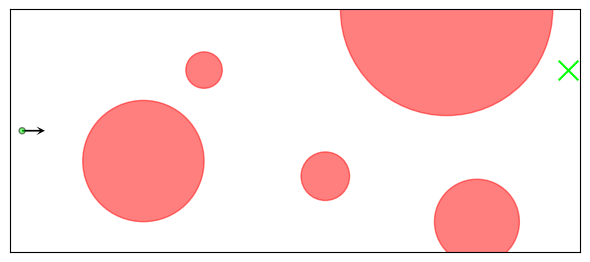

<Figure size 1200x1200 with 0 Axes>

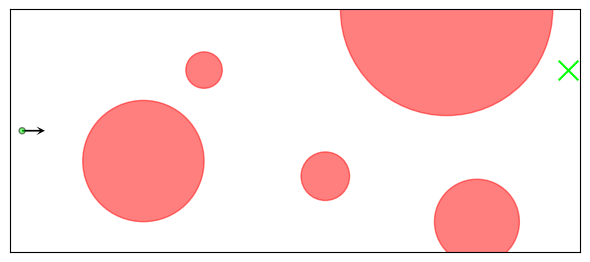

In [7]:
env = gym.make('NavigationEnvPololu-v0', 
               render_mode="human",
               dt=1.0,
               atol=0.3,
               rtol=0.0,
               multi_step_count=10,
               obstacle_mode="circles",
               render_sleep=0.1,
               sparse_reward=True,
               )
env.reset(seed=42)
env.render()


In [8]:
env.unwrapped.agent.action_sampler_method

'uniform_steering'

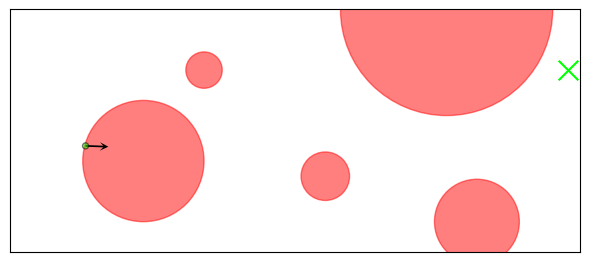

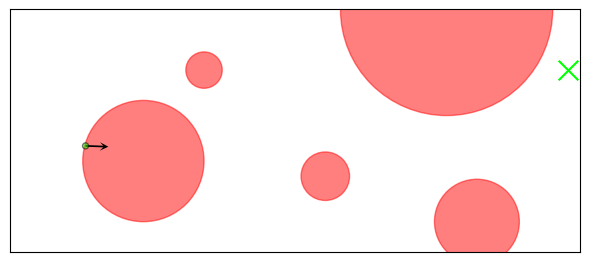

INFO:tools.envs.navigation_envs.navigation_env:WARNING: No seed provided to env.reset(). Using random seed: None
INFO:tools.envs.navigation_envs.navigation_env:Using provided seed: None


---- NavigationEnvSingleIntegratorUnicycle reset called with seed: None and options: None
start_obs: [0. 3. 0. 0. 9. 4.] goal_obs: [ 9.  4. nan nan  9.  4.]


In [9]:
# Random movements
env.reset()
for _ in range(20):
    action = env.action_space.sample()
    observation, reward, done, truncated, info = env.step(action)
    env.render()
    sleep(0.1)
    if done or truncated:
        observation = env.reset()

In [10]:
computational_budget_max = 500
time_budget_max = 0.2  # seconds

In [26]:
# Pololu Planner Configuration
planner = planners.MCGSPlanner(env=env.unwrapped,
                               budget_per_step=1,
                               computational_budget_max=computational_budget_max,
                               time_budget_max=time_budget_max,
                               expand_n_times=1,
                               expand_n_times_min=1,
                               expand_n_times_max=1,
                               sample_best_X_actions=5,
                               kappa=0.5,
                               alpha=0.2,
                               k=30,
                               radius_threshold=1.0,
                               progressive_widening_method="dispersion",
                               epsilon=0.1,
                               abstraction_refinement_exponent=-0.0,
                               c_uct=0.5,
                               plan_in_space_time=False,
                               use_controller=True,
                               tracking_tolerance=0.5,
                               yield_mode='N',
                               random_rollout_n_times=1,
                               random_rollout_length=4,
                               force_exact_update=False,
                               controller_expansion_check=False)


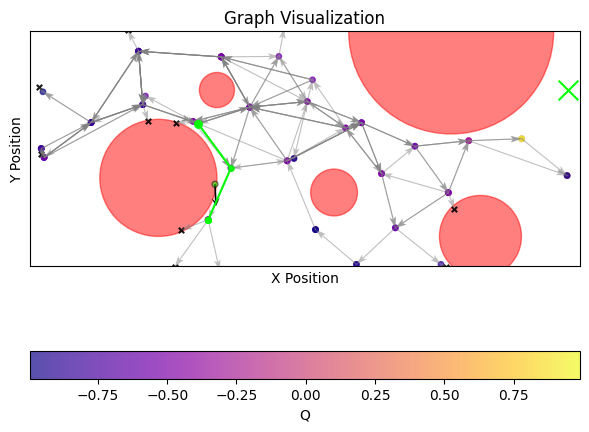

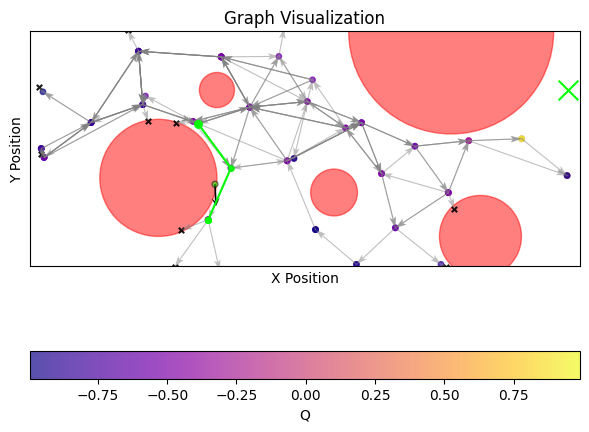

Episode finished! Total reward: -0.6399999999999999 after 37 iterations with computational budget used 5/330


In [27]:
episode_over = False
total_reward = 0

planner.reset()
try:
    # planner.plan(iterations=20, expand_n_times=10) # Bootstrapping
    pass
except Exception as e:
    print("Exception during bootstrapping planning:")
    print(e)
i = 0
while not episode_over:
    print(f"--- Episode step {i} ---")

    # planner.plan(iterations=250, expand_n_times=1)
    print("Agent state:", planner.env.agent.state)
    observation, reward, terminated, truncated, info = planner.plan_online(render=False, time=True, computational=False, use_hardware=False)
    print("Agent state after step:", planner.env.agent.state)
    # sleep(1.0) 
    # planner.render()
    print('root node id', planner.root_node_id)
    try:
        # get_stats()
        plan = planner.planned_trajectory['node_ids']
        plan_action_list = planner.planned_trajectory['action_list']
        plan_dt_list = planner.planned_trajectory['dt_list']
        print(f"Episode step {i}: current state: {planner.env.agent.state}, plan: {plan}, actions: {plan_action_list}, dts: {plan_dt_list}")
        print(f"Computational budget used: {planner.computational_budget_used}/{planner.computational_budget_total}")
        print(f"Time budget used: {planner.time_budget_used:.4f}/{planner.time_budget_total:.4f}")
        print(f"Episode step {i}: took action {plan_action_list[0]} to {observation}, got reward {reward}, terminated={terminated}, truncated={truncated}")
    except Exception as e:
        print(f"Episode step {i}: current state: {planner.env.agent.state}, no plan found!")
        print(e)

    total_reward += reward
    episode_over = terminated or truncated
    i += 1
    # if i >0:
    #     break
    sleep(.01)
    planner.render()
print(f"Episode finished! Total reward: {total_reward} after {i} iterations with computational budget used {planner.computational_budget_used}/{planner.computational_budget_total}")

env.close()


In [13]:
planner.graph.successor_indices(planner.root_node_id)

NodeIndices[57, 51, 96, 38, 37]

In [14]:
print(planner.graph[planner.root_node_id].state, planner.env.agent.state)

[ 2.80874593  3.6737326  -0.44489907  5.99999999] [ 2.60754319  3.28873272 -0.44489923 72.89196563]


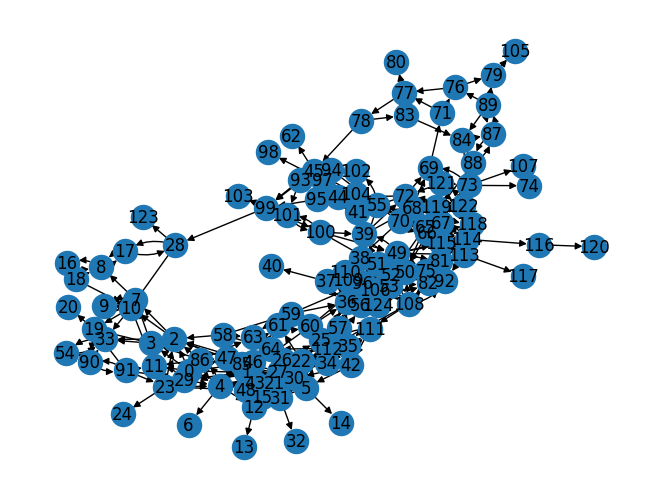

In [15]:
from rustworkx.visualization import mpl_draw
mpl_draw(planner.graph, with_labels=True)

In [16]:
planner.root_node_id

np.uint64(36)

In [17]:
planner.yield_plan()

([np.uint64(36),
  96,
  39,
  68,
  69,
  71,
  77,
  78,
  83,
  84,
  87,
  88,
  73,
  66,
  67,
  70,
  72,
  44,
  55,
  65,
  52,
  53,
  56,
  37,
  38,
  41,
  45,
  93,
  94,
  97,
  95,
  99,
  100,
  49,
  50,
  51,
  75,
  82,
  81,
  92,
  108,
  106,
  124,
  109],
 [[array([0.0412086 , 0.94361768]),
   array([0.05439099, 0.77245891]),
   array([0.11057462, 0.29956812]),
   array([0.17203288, 0.14509722]),
   array([0.19765869, 0.03813849]),
   array([ 0.20087887, -0.06143646]),
   array([ 0.18359553, -0.16901246]),
   array([ 0.14261378, -0.30258199]),
   array([ 0.0813566 , -0.53073418]),
   array([ 0.04226731, -0.93940355])],
  [array([ 0.17807588, -0.63577087]),
   array([ 0.37888138, -0.20893086]),
   array([ 0.37257851, -0.18901488]),
   array([ 0.38400884, -0.13830958]),
   array([ 0.39394736, -0.08037484]),
   array([ 0.39955651, -0.0149105 ]),
   array([0.39876034, 0.06443652]),
   array([0.38618531, 0.17444688]),
   array([0.34023066, 0.37437796]),
   array([0.

# Legacy (for debugging)

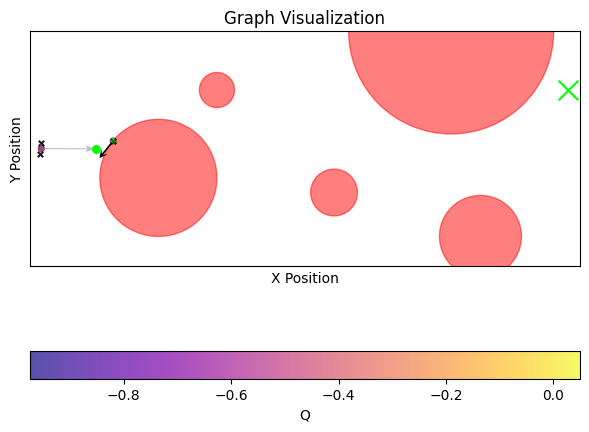

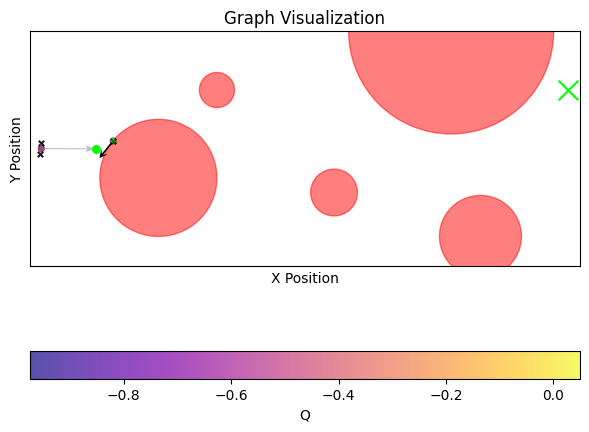

Episode finished! Total reward: -0.98 after 3 iterations with computational budget used 1/542


In [18]:
episode_over = False
total_reward = 0

planner.reset()
try:
    # planner.plan(iterations=20, expand_n_times=10) # Bootstrapping
    pass
except Exception as e:
    print("Exception during bootstrapping planning:")
    print(e)
# planner.plan_while_in_budget()
i = 0
while not episode_over:
    print(f"--- Iteration {i} ---")

    # planner.plan(iterations=250, expand_n_times=1)
    print("Agent state:", planner.env.agent.state)
    observation, reward, terminated, truncated, info = planner.plan_and_step(render=True, computational=True, time=True)
    print("Agent state after step:", planner.env.agent.state)
    # sleep(1.0) 
    # planner.render()
    try:
        # get_stats()
        plan, plan_action_list, plan_dt_list = planner.yield_plan(max_length=100)
        print(f"Iteration {i}: current state: {planner.env.agent.state}, plan: {plan}, actions: {plan_action_list}, dts: {plan_dt_list}")
        print(f"Computational budget used: {planner.computational_budget_used}/{planner.computational_budget_total}")
        print(f"Time budget used: {planner.time_budget_used:.4f}/{planner.time_budget_total:.4f}")
        print(f"Step {i}: took action {plan_action_list[0]} to {observation}, got reward {reward}, terminated={terminated}, truncated={truncated}")
    except Exception as e:
        print(f"Iteration {i}: current state: {planner.env.agent.state}, no plan found!")
        print(e)

    total_reward += reward
    episode_over = terminated or truncated
    i += 1
    # sleep(5)
planner.render()
print(f"Episode finished! Total reward: {total_reward} after {i} iterations with computational budget used {planner.computational_budget_used}/{planner.computational_budget_total}")

env.close()


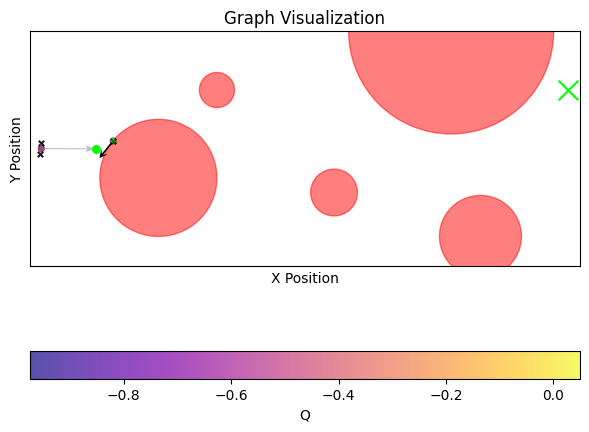

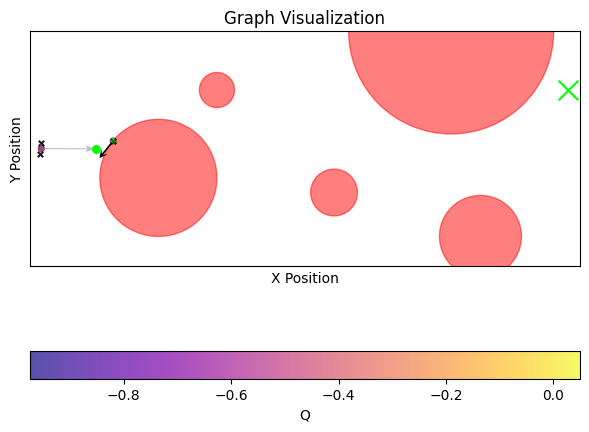

In [19]:
planner.render()


In [20]:
planner.env.agent.action_space.sample()

array([0.1260339, 1.5434422], dtype=float32)

In [21]:
planner.graph[planner.root_node_id]

NodePayload(id=9, state=[ 1.22796739  3.13118666 -2.24433739  8.92118525], N=1, U=-2.0, Q=-2.0, is_finished=False, is_truncated=True)

In [22]:
planner.env.observation_space

Box([ 0.         1.        -3.1415927  0.         0.         1.       ], [9.        5.        3.1415927       inf 9.        5.       ], (6,), float32)

In [23]:
planner.observation_replay

[array([0., 3., 0., 0., 9., 4.], dtype=float32),
 array([ 1.0699176e-04,  2.9999671e+00, -5.9672177e-01,  3.4888866e+00,
         9.0000000e+00,  4.0000000e+00], dtype=float32),
 array([0.97321576, 3.2020235 , 0.6006936 , 5.908877  , 9.        ,
        4.        ], dtype=float32)]

In [24]:
np.random.random(size=(20,3),) * np.array([10,6,1]).round(decimals=2)

array([[1.69600360e+00, 2.64528684e+00, 4.89477394e-01],
       [7.14055849e+00, 4.58748320e+00, 4.73316703e-01],
       [3.07902908e+00, 2.65757398e+00, 9.23715643e-01],
       [9.65093893e+00, 4.67926448e-01, 6.24106501e-01],
       [4.86817643e+00, 2.87094640e+00, 9.34464449e-01],
       [2.42792717e+00, 1.68482498e+00, 3.10426013e-01],
       [3.43943190e+00, 4.21599405e+00, 7.89951729e-01],
       [6.34137633e-01, 4.73375644e+00, 7.48172516e-01],
       [8.68069660e+00, 2.35206483e+00, 4.03321598e-01],
       [9.63343537e+00, 1.97398074e-02, 2.16189989e-01],
       [1.59517592e+00, 2.63597637e-03, 4.72441709e-02],
       [1.11782352e+00, 3.26874262e+00, 2.02836760e-01],
       [3.39651942e+00, 5.90805783e+00, 5.22474318e-01],
       [1.92170073e+00, 2.52445781e+00, 4.31365767e-02],
       [7.19338802e+00, 2.01817936e+00, 3.06755411e-01],
       [1.24815228e+00, 4.69181765e+00, 5.02116847e-01],
       [5.33031748e+00, 3.75434286e+00, 4.12234647e-01],
       [3.59836809e+00, 3.85600

In [25]:
planner.env.agent

Robot(id=0, name=Pololu, state=[ 1.22796739  3.13118666 -2.24433739  8.92118525])